1. Bibliothèques importées avec succès.

2. Données DIABETES chargées. Taille : (442, 11)
   Target : Progression quantitative de la maladie diabétique
   Description : 

3. Introduction artificielle de valeurs manquantes (5%)...
   Valeurs manquantes créées : 220

4. Nettoyage des données...
   Imputation terminée (NaN → moyenne).
   NaN restants : 0

5. Analyse Exploratoire (EDA)...
   Statistiques (5 premières features) :
              age         sex         bmi          bp          s1
count  442.000000  442.000000  442.000000  442.000000  442.000000
mean    -0.000195   -0.001066   -0.000596   -0.000624   -0.000209
std      0.046045    0.046341    0.046560    0.046403    0.046157
min     -0.107226   -0.044642   -0.090275   -0.112399   -0.126781
25%     -0.033667   -0.044642   -0.033151   -0.033213   -0.032872
50%      0.001751   -0.044642   -0.005128   -0.005670   -0.001569
75%      0.034443    0.050680    0.026128    0.029610    0.024574
max      0.110727    0.050680    0.170555  

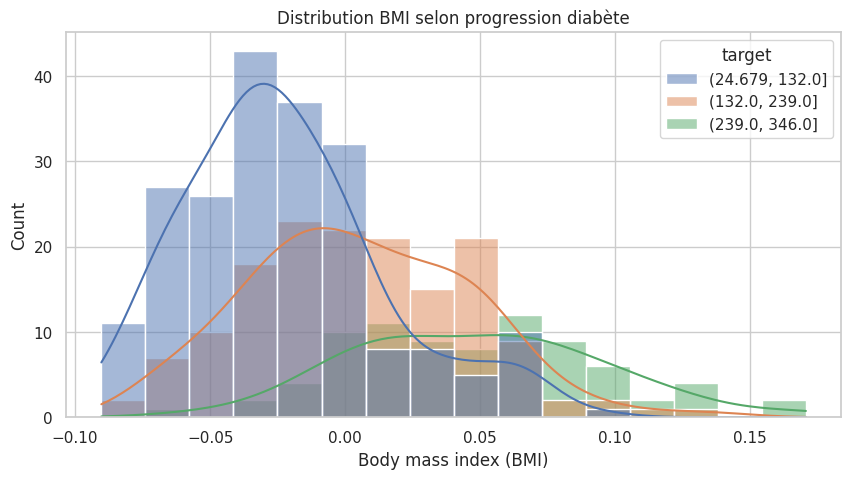

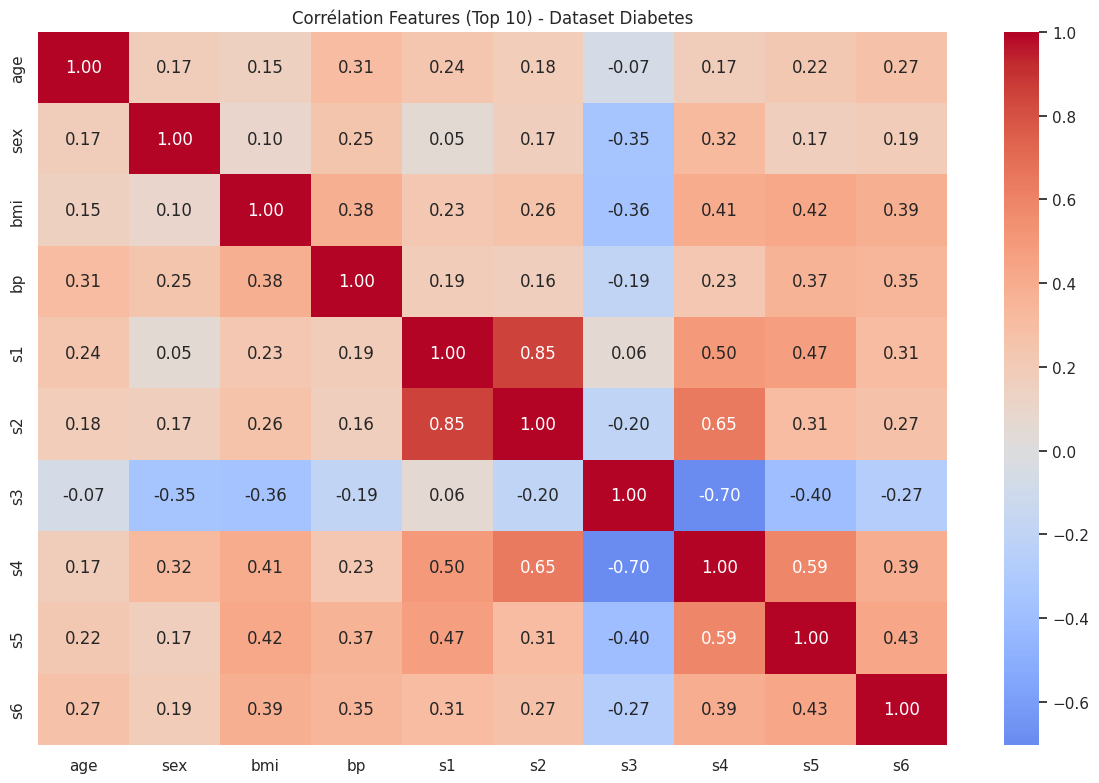

6. Séparation :
   Train : 353 échantillons
   Test  : 89 échantillons

7. Entraînement Random Forest Regressor...
   Modèle entraîné.

8. Évaluation performances...
   >>> RMSE : 54.28
   >>> R² Score : 0.444
   >>> Écart-type target : 73.20

   Top 10 features importantes :
  feature  importance
2     bmi    0.339687
8      s5    0.221746
3      bp    0.093413
5      s2    0.061507
0     age    0.060933
4      s1    0.060734
9      s6    0.060626
6      s3    0.056846
7      s4    0.031736
1     sex    0.012773


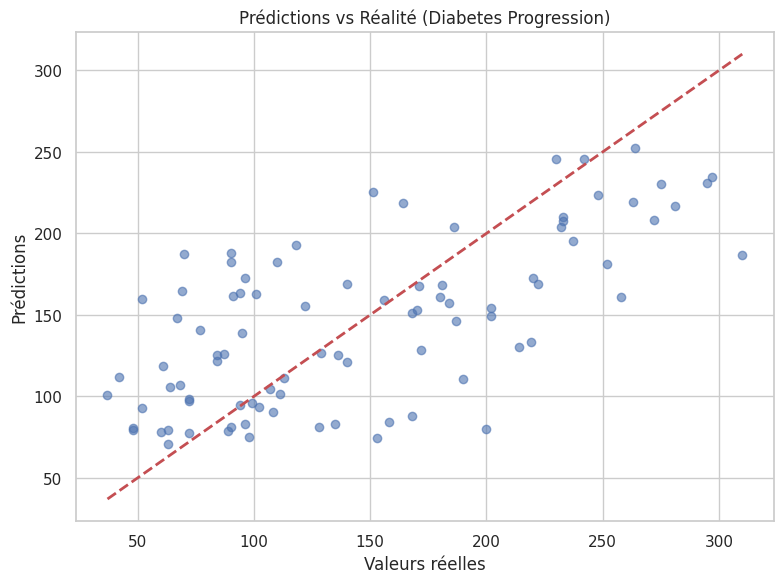

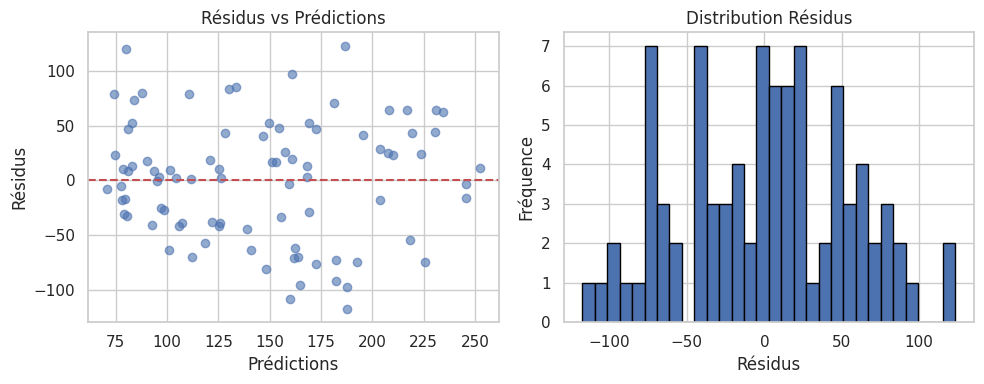


--- SCRIPT DIABETES TERMINÉ ---
✅ Pipeline complet : Chargement → Nettoyage → EDA → Modélisation → Évaluation


In [5]:
# ==============================================================================
# COURS DATA SCIENCE : CYCLE DE VIE COMPLET (SCRIPT PÉDAGOGIQUE) - DIABETES
# Auteur : Votre Professeur IA - ADAPTÉ AU DATASET DIABETES
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modules Scikit-Learn spécifiques
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor  # CHANGÉ pour régression
from sklearn.metrics import mean_squared_error, r2_score

# Configuration pour des graphiques plus esthétiques
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
print("1. Bibliothèques importées avec succès.\n")

# ------------------------------------------------------------------------------
# 2. CHARGEMENT DES DONNÉES DIABETES
# ------------------------------------------------------------------------------
# Chargement du dataset DIABETES (régression continue)
data = load_diabetes()

# Création du DataFrame Pandas
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # Progression quantitative de la maladie

print(f"2. Données DIABETES chargées. Taille : {df.shape}")
print(f"   Target : Progression quantitative de la maladie diabétique")
print(f"   Description : {data.DESCR.splitlines()[1]}\n")

# ------------------------------------------------------------------------------
# 3. SIMULATION DE "DONNÉES SALES" (5% NaN)
# ------------------------------------------------------------------------------
print("3. Introduction artificielle de valeurs manquantes (5%)...")
np.random.seed(42)
features_columns = df.columns[:-1]
df_dirty = df.copy()
for col in features_columns:
    df_dirty.loc[df_dirty.sample(frac=0.05).index, col] = np.nan

print(f"   Valeurs manquantes créées : {df_dirty.isnull().sum().sum()}\n")

# ------------------------------------------------------------------------------
# 4. NETTOYAGE ET PRÉPARATION
# ------------------------------------------------------------------------------
print("4. Nettoyage des données...")
X = df_dirty.drop('target', axis=1)
y = df_dirty['target']

# Imputation par la moyenne
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X_clean = pd.DataFrame(X_imputed, columns=X.columns)

print("   Imputation terminée (NaN → moyenne).")
print(f"   NaN restants : {X_clean.isnull().sum().sum()}\n")

# ------------------------------------------------------------------------------
# 5. ANALYSE EXPLORATOIRE (EDA) - ADAPTÉ DIABETES
# ------------------------------------------------------------------------------
print("5. Analyse Exploratoire (EDA)...")

# A. Statistiques descriptives
print("   Statistiques (5 premières features) :")
print(X_clean.iloc[:, :5].describe())

# B. Distribution BMI (feature clé pour diabète)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='bmi', hue=pd.cut(df['target'], bins=3), kde=True)
plt.title("Distribution BMI selon progression diabète")
plt.xlabel("Body mass index (BMI)")
plt.show()

# C. Heatmap corrélation (10 premières)
plt.figure(figsize=(12, 8))
corr_matrix = X_clean.iloc[:, :10].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Corrélation Features (Top 10) - Dataset Diabetes")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. SÉPARATION TRAIN/TEST
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

print(f"6. Séparation :")
print(f"   Train : {X_train.shape[0]} échantillons")
print(f"   Test  : {X_test.shape[0]} échantillons\n")

# ------------------------------------------------------------------------------
# 7. MODÉLISATION - Random Forest Régression
# ------------------------------------------------------------------------------
print("7. Entraînement Random Forest Regressor...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("   Modèle entraîné.\n")

# ------------------------------------------------------------------------------
# 8. ÉVALUATION PERFORMANCE (RÉGRESSION)
# ------------------------------------------------------------------------------
print("8. Évaluation performances...")

# Prédictions
y_pred = model.predict(X_test)

# Métriques régression
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"   >>> RMSE : {rmse:.2f}")
print(f"   >>> R² Score : {r2:.3f}")
print(f"   >>> Écart-type target : {y_test.std():.2f}")

# Feature importance (top 10)
importances = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

print("\n   Top 10 features importantes :")
print(importances)

# Visualisation prédictions vs réelles
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs réelles')
plt.ylabel('Prédictions')
plt.title('Prédictions vs Réalité (Diabetes Progression)')
plt.tight_layout()
plt.show()

# Matrice résidus
residuals = y_test - y_pred
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Prédictions')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.title('Distribution Résidus')
plt.tight_layout()
plt.show()

print("\n--- SCRIPT DIABETES TERMINÉ ---")
print("✅ Pipeline complet : Chargement → Nettoyage → EDA → Modélisation → Évaluation")
